#Customer Churn Prediction


## Problem Statement

Customer churn is a major challenge for telecommunications companies because losing existing customers can reduce recurring revenue and increase customer acquisition costs.

This project analyzes customer demographics, service usage, contract details, and billing information from the **Telcom Customer Churn Dataset** to identify patterns associated with customer churn.

The main objective is to build a machine learning classification model that predicts whether a customer is likely to churn and to identify the customer characteristics most strongly associated with churn.

The analysis uses Python for data analysis and visualization, followed by Logistic Regression and XGBoost classification models.

## Install Required Libraries

The project uses Python libraries for data manipulation, visualization, and machine learning.

The following installation is intended for **Google Colab**. If the libraries are already installed in the environment, this step can be skipped.

In [1]:
# Install required libraries for Google Colab
!pip install seaborn xgboost scikit-learn --quiet

## Import Libraries

The following libraries are used for data manipulation, visualization, exploratory analysis, and machine learning.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Google Colab
from google.colab import drive

# Reproducibility
RANDOM_STATE = 42

# Plot style
sns.set_style("whitegrid")

## Load Dataset

The dataset is stored in Google Drive and loaded into a Pandas DataFrame for analysis.

The Kaggle dataset contains customer-level information including demographics, tenure, subscribed services, contract type, payment method, monthly charges, total charges, and churn status.

In [4]:
# Mount Google Drive
drive.mount('/content/drive')

# Path to the dataset
file_path = '/content/drive/MyDrive/customer_churn_prediction/data.csv'

# Load dataset
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

Mounted at /content/drive
Dataset loaded successfully.
Dataset shape: (7043, 21)


### Initial Dataset Inspection

Before cleaning the data, we inspect its dimensions, structure, and missing values.

In [5]:
# Display the first five rows
display(df.head())

# Check column names and data types
print("Data types:")
display(df.dtypes)

# Check missing values
print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Data types:


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Missing values:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Data Cleaning & Preparation

The initial inspection shows that most variables have appropriate data types and there are no explicit missing values.

However, `TotalCharges` is stored as a text (`object`) column even though it represents a numerical monetary value. This needs to be converted to numeric before analysis and modeling.

We will:

- Convert `TotalCharges` to a numeric data type
- Identify any values that cannot be converted
- Remove invalid records if necessary
- Encode the target variable `Churn` as binary values:
  - `Yes` → 1
  - `No` → 0
- Verify the resulting dataset

In [6]:
# Make a copy before cleaning
df = df.copy()

# Convert TotalCharges from text to numeric
# Invalid/non-numeric values will become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many values became missing after conversion
invalid_total_charges = df['TotalCharges'].isna().sum()

print(f"Invalid TotalCharges values after conversion: {invalid_total_charges}")

# Remove rows with invalid TotalCharges
if invalid_total_charges > 0:
    df = df.dropna(subset=['TotalCharges']).copy()

# Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}).astype('int8')

# Reset index after removing rows
df.reset_index(drop=True, inplace=True)

print(f"\nFinal dataset shape: {df.shape}")

print("\nData types after cleaning:")
display(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].dtypes)

print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())

print("\nChurn values:")
print(df['Churn'].value_counts().sort_index())

Invalid TotalCharges values after conversion: 11

Final dataset shape: (7032, 21)

Data types after cleaning:


,0
tenure,int64
MonthlyCharges,float64
TotalCharges,float64
Churn,int8



Missing values after cleaning:
0

Churn values:
Churn
0    5163
1    1869
Name: count, dtype: int64


### Cleaning Results

The dataset initially contained 7,043 customer records. During data cleaning, `TotalCharges` was converted from text to a numeric variable. This revealed **11 records with invalid or non-numeric values**, which were removed.

The cleaned dataset contains **7,032 customers and 21 variables**, with no remaining missing values.

The target variable `Churn` was encoded as:
- `0` = Customer did not churn
- `1` = Customer churned

There are **5,163 non-churned customers** and **1,869 churned customers**, indicating that churn is an imbalanced classification problem. Therefore, model evaluation should consider metrics such as **precision, recall, F1-score, and ROC-AUC**, rather than relying on accuracy alone.

## Churn Distribution

Before building a predictive model, we examine the distribution of the target variable.

Understanding the proportion of churned and retained customers is important because an imbalanced target can affect how model performance should be evaluated.

,Customer Status,Count,Percentage
0,Stayed,5163,73.42
1,Churned,1869,26.58


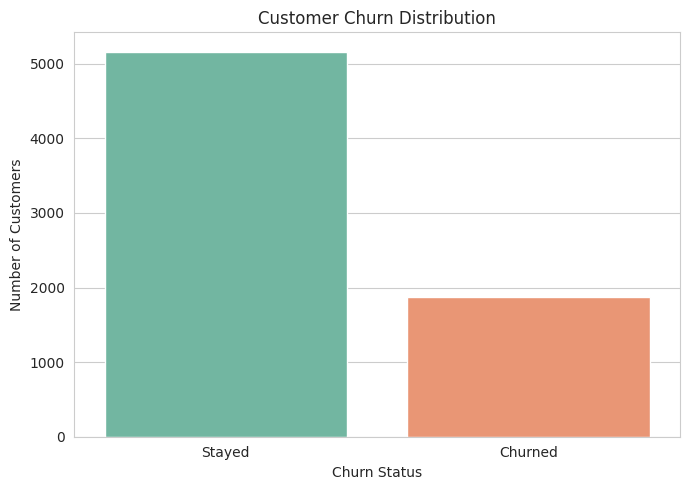

In [7]:
# Calculate churn counts and percentages
churn_counts = df['Churn'].value_counts().sort_index()
churn_percent = (churn_counts / len(df) * 100).round(2)

# Display summary
churn_summary = pd.DataFrame({
    'Customer Status': ['Stayed', 'Churned'],
    'Count': churn_counts.values,
    'Percentage': churn_percent.values
})

display(churn_summary)

# Plot churn distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Churn',
    hue='Churn',
    palette='Set2',
    legend=False
)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['Stayed', 'Churned'])

plt.tight_layout()
plt.show()

### Observation

Of the 7,032 customers in the cleaned dataset, **5,163 (73.42%) stayed** with the company, while **1,869 (26.58%) churned**.

This shows a moderate class imbalance, with churned customers representing approximately one-quarter of the dataset. Since identifying churned customers is the primary business objective, **accuracy alone may not provide a complete picture of model performance**.

Therefore, model evaluation will focus on **precision, recall, F1-score, and ROC-AUC**, alongside accuracy. In particular, recall will be important because failing to identify a customer who eventually churns could result in a missed retention opportunity.

## Churn Rate by Customer Tenure

Customer tenure represents the number of months a customer has been with the company. Examining churn across tenure groups can help identify whether customers are more vulnerable to churn during particular stages of their relationship with the company.

,Tenure Group (Months),Customers,Churn Rate (%)
0,0-12,2175,47.68
1,13-24,1024,28.71
2,25-48,1594,20.39
3,49-60,832,14.42
4,61-72,1407,6.61


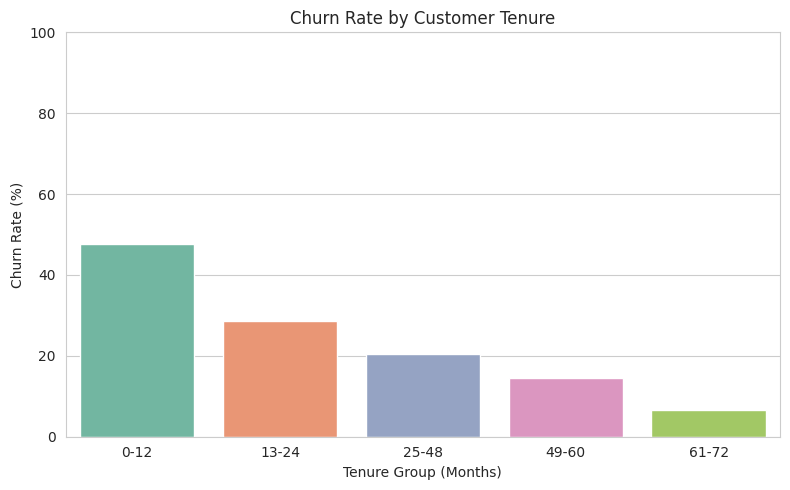

In [8]:
# Create tenure groups
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 60, 72],
    labels=['0-12', '13-24', '25-48', '49-60', '61-72'],
    include_lowest=True
)

# Calculate churn rate for each tenure group
tenure_churn = (
    df.groupby('tenure_group', observed=True)['Churn']
      .agg(['count', 'mean'])
      .reset_index()
)

tenure_churn['churn_rate'] = (tenure_churn['mean'] * 100).round(2)

# Display results
display(
    tenure_churn[['tenure_group', 'count', 'churn_rate']]
    .rename(columns={
        'tenure_group': 'Tenure Group (Months)',
        'count': 'Customers',
        'churn_rate': 'Churn Rate (%)'
    })
)

# Plot churn rate
plt.figure(figsize=(8, 5))

sns.barplot(
    data=tenure_churn,
    x='tenure_group',
    y='churn_rate',
    hue='tenure_group',
    palette='Set2',
    legend=False
)

plt.title('Churn Rate by Customer Tenure')
plt.xlabel('Tenure Group (Months)')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

### Observation

Churn is strongly associated with customer tenure. Customers in their first 12 months have the highest churn rate at **47.68%**, compared with only **6.61%** among customers with 61–72 months of tenure.

The churn rate decreases consistently as tenure increases:

- **0–12 months:** 47.68%
- **13–24 months:** 28.71%
- **25–48 months:** 20.39%
- **49–60 months:** 14.42%
- **61–72 months:** 6.61%

This suggests that the **early stage of the customer lifecycle is a particularly high-risk period**. From a business perspective, retention efforts may therefore be especially valuable during the first year of a customer's relationship with the company.

## Contract Type and Churn

Contract structure may influence customer retention because longer-term contracts can create greater commitment and reduce the likelihood of customers leaving.

We compare churn rates across month-to-month, one-year, and two-year contracts.

,Contract,Customers,Churn Rate (%)
0,Month-to-month,3875,42.71
1,One year,1472,11.28
2,Two year,1685,2.85


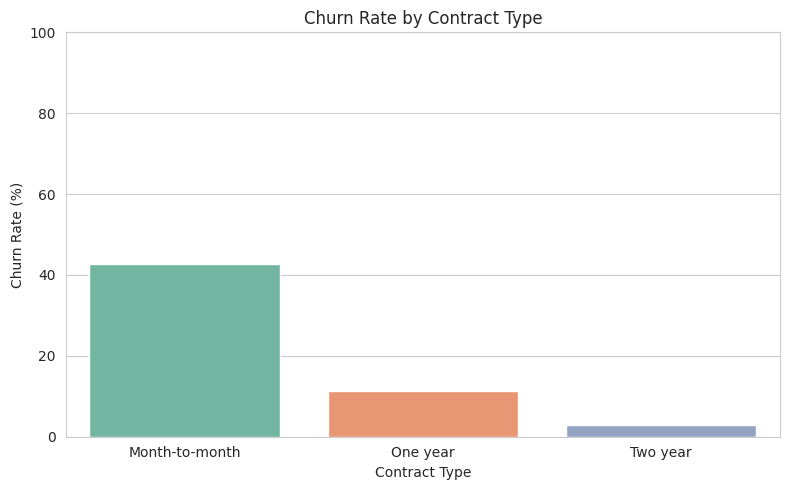

In [11]:
# Calculate churn rate by contract type
contract_churn = (
    df.groupby('Contract')['Churn']
      .agg(['count', 'mean'])
      .reset_index()
)

contract_churn['churn_rate'] = (contract_churn['mean'] * 100).round(2)

# Display results
display(
    contract_churn[['Contract', 'count', 'churn_rate']]
    .rename(columns={
        'count': 'Customers',
        'churn_rate': 'Churn Rate (%)'
    })
    .sort_values('Churn Rate (%)', ascending=False)
)

# Plot
plt.figure(figsize=(8, 5))

sns.barplot(
    data=contract_churn,
    x='Contract',
    y='churn_rate',
    hue='Contract',
    palette='Set2',
    legend=False
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)

plt.tight_layout()
plt.show()


### Observation

Contract type shows a strong association with customer churn.

**Month-to-month customers have the highest churn rate at 42.71%**, compared with **11.28% for one-year contracts** and only **2.85% for two-year contracts**.

This makes contract type an important candidate feature for the predictive model. From a business perspective, month-to-month customers may also represent a priority segment for retention initiatives.

> These results indicate an association between contract type and churn; they do not establish that contract type directly causes churn.

## Internet Service and Churn

Internet service type may influence customer retention because different service types can be associated with different pricing, service experiences, and customer needs.

We compare churn rates across DSL, fiber optic, and customers without internet service.

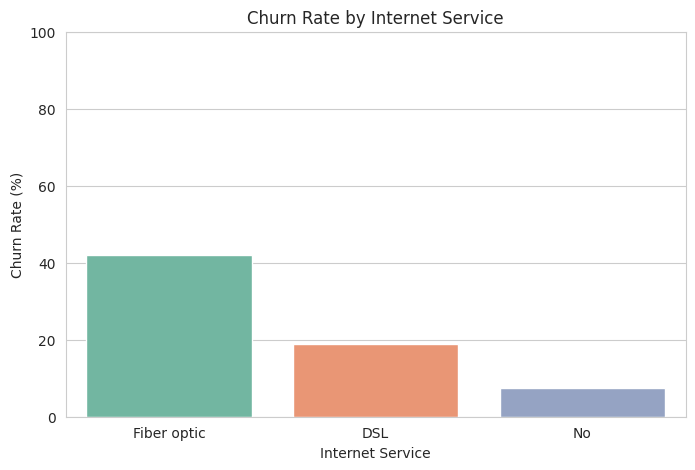

,Customers,Churn_Rate
InternetService,,
Fiber optic,3096,41.89
DSL,2416,19.00
No,1520,7.43


In [12]:
# Calculate churn rate by internet service
internet_summary = (
    df.groupby('InternetService', observed=True)
      .agg(
          Customers=('Churn', 'size'),
          Churn_Rate=('Churn', 'mean')
      )
      .sort_values('Churn_Rate', ascending=False)
)

internet_summary['Churn_Rate'] = (
    internet_summary['Churn_Rate'] * 100
).round(2)

# Plot
plt.figure(figsize=(8, 5))

sns.barplot(
    data=internet_summary.reset_index(),
    x='InternetService',
    y='Churn_Rate',
    hue='InternetService',
    palette='Set2',
    legend=False
)

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 100)
plt.show()

display(internet_summary)

### Observation

Internet service type is strongly associated with churn in this dataset.

Customers with **fiber optic service have the highest churn rate at 41.89%**, compared with **19.00% for DSL customers** and **7.43% for customers without internet service**.

The relatively high churn among fiber optic customers suggests that internet service type may be an important predictor of churn. However, this relationship may also reflect other customer characteristics, such as contract type, tenure, and monthly charges, which will be considered together during model development.

## Payment Method and Churn

Payment method can provide insight into customer billing preferences and may be associated with differences in churn behavior.

We compare churn rates across the available payment methods.

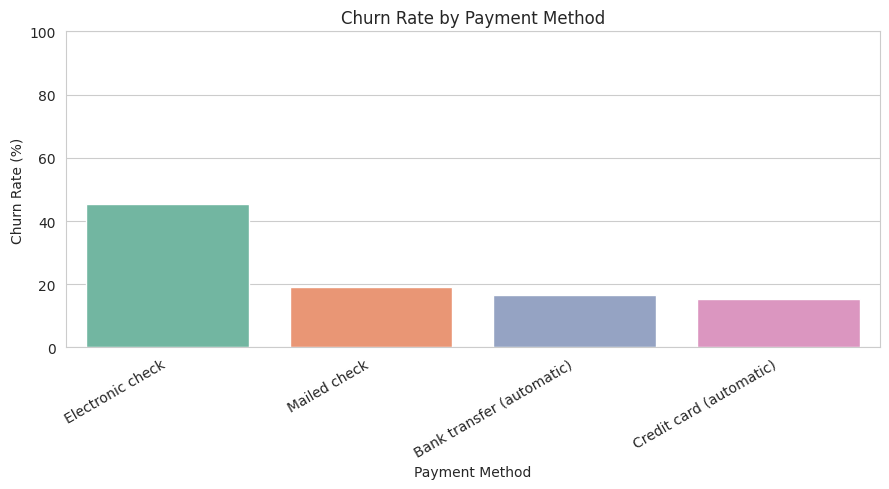

,Customers,Churn_Rate
PaymentMethod,,
Electronic check,2365,45.29
Mailed check,1604,19.20
Bank transfer (automatic),1542,16.73
Credit card (automatic),1521,15.25


In [13]:
# Calculate churn rate by payment method
payment_summary = (
    df.groupby('PaymentMethod', observed=True)
      .agg(
          Customers=('Churn', 'size'),
          Churn_Rate=('Churn', 'mean')
      )
      .sort_values('Churn_Rate', ascending=False)
)

payment_summary['Churn_Rate'] = (
    payment_summary['Churn_Rate'] * 100
).round(2)

# Plot
plt.figure(figsize=(9, 5))

sns.barplot(
    data=payment_summary.reset_index(),
    x='PaymentMethod',
    y='Churn_Rate',
    hue='PaymentMethod',
    palette='Set2',
    legend=False
)

plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

display(payment_summary)

### Observation

Payment method is also associated with substantially different churn rates.

Customers using **electronic check have the highest churn rate at 45.29%**, considerably higher than mailed check (19.20%), automatic bank transfer (16.73%), and automatic credit card payments (15.25%).

This makes payment method a useful candidate feature for churn prediction. The difference may also indicate that billing behavior is associated with customer retention, although the relationship may overlap with other factors such as contract type, tenure, and monthly charges.

## Numerical Features and Churn

We now compare key numerical variables between customers who stayed and those who churned.

The analysis focuses on:

- Tenure
- Monthly charges
- Total charges

These variables represent customer relationship length and spending behavior.

tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
0      37.65   38.0          61.31  64.45      2555.34  1683.60
1      17.98   10.0          74.44  79.65      1531.80   703.55

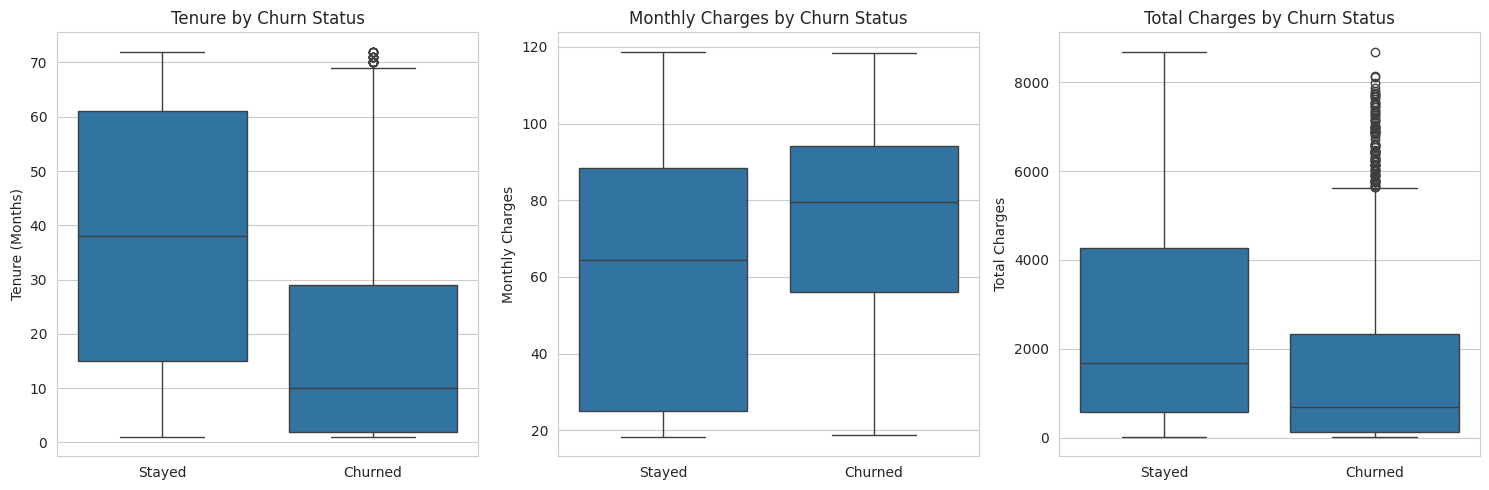

In [15]:
# Compare numerical variables by churn status
numerical_summary = (
    df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']]
      .agg(['mean', 'median'])
      .round(2)
)

display(numerical_summary)

# Prepare data for visualization
plot_data = df.copy()
plot_data['Churn Status'] = plot_data['Churn'].map({
    0: 'Stayed',
    1: 'Churned'
})

# Create separate boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=plot_data, x='Churn Status', y='tenure', ax=axes[0])
axes[0].set_title('Tenure by Churn Status')
axes[0].set_xlabel('')
axes[0].set_ylabel('Tenure (Months)')

sns.boxplot(data=plot_data, x='Churn Status', y='MonthlyCharges', ax=axes[1])
axes[1].set_title('Monthly Charges by Churn Status')
axes[1].set_xlabel('')
axes[1].set_ylabel('Monthly Charges')

sns.boxplot(data=plot_data, x='Churn Status', y='TotalCharges', ax=axes[2])
axes[2].set_title('Total Charges by Churn Status')
axes[2].set_xlabel('')
axes[2].set_ylabel('Total Charges')

plt.tight_layout()
plt.show()

### Observation

The numerical variables show clear differences between customers who stayed and those who churned.

Churned customers have substantially lower tenure, with an average tenure of **17.98 months** compared with **37.65 months** among customers who stayed. This is consistent with the earlier tenure-group analysis, where newer customers showed considerably higher churn rates.

Churned customers also have higher monthly charges on average (**74.44** vs. **61.31**), suggesting that higher monthly billing may be associated with increased churn risk.

Although churned customers have lower average total charges (**1531.80** vs. **2555.34**), this is largely consistent with their shorter tenure. Therefore, `TotalCharges` should be considered together with tenure rather than interpreted as an independent indicator of churn.

These findings support retaining **tenure, MonthlyCharges, and TotalCharges** as predictive features.

## Feature Engineering

A small number of business-relevant features are created before modeling.

In addition to the original variables, we create:

- **Service Count:** number of additional services subscribed to across security, backup, device protection, technical support, and streaming services.
- **Tenure Group:** a categorical representation of customer tenure used for exploratory analysis.

The goal is to create interpretable features without unnecessarily increasing model complexity.

In [16]:
# Create a count of additional services
service_columns = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['service_count'] = (
    df[service_columns]
    .apply(lambda row: row.isin(['Yes']).sum(), axis=1)
)

# Check the new feature
display(
    df[['tenure', 'service_count', 'MonthlyCharges', 'Churn']].head()
)

print("\nService count distribution:")
display(df['service_count'].value_counts().sort_index())

,tenure,service_count,MonthlyCharges,Churn
0,1,1,29.85,0
1,34,2,56.95,0
2,2,2,53.85,1
3,45,3,42.30,0
4,2,0,70.70,1



Service count distribution:


,count
service_count,
0,2213
1,966
2,1033
3,1117
4,850
5,569
6,284


### Observation

The engineered `service_count` feature ranges from **0 to 6 additional services**.

Most customers have between 0 and 3 additional services, while relatively fewer customers have 5 or 6. This feature provides a compact measure of service adoption that can be used alongside individual service variables during modeling.

Because the feature is based only on services marked as active (`Yes`), it remains interpretable as a simple measure of customer service engagement.

## Prepare Data for Machine Learning

The cleaned dataset contains both numerical and categorical variables. Machine learning models require categorical variables to be converted into numerical representations.

Before preprocessing, the target variable (`Churn`) is separated from the predictors.

The customer identifier is excluded because it is an identifier rather than a meaningful predictive feature.

The data is split into training and testing sets using stratification so that the proportion of churned customers remains similar in both sets.

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Separate target and predictors
X = df.drop(columns=['Churn', 'customerID', 'tenure_group', 'tenure_group_code'], errors='ignore')
y = df['Churn']

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'int32', 'float64', 'int8']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining churn rate:", round(y_train.mean() * 100, 2), "%")
print("Testing churn rate:", round(y_test.mean() * 100, 2), "%")

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'service_count']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Training set: (5625, 20)
Testing set: (1407, 20)

Training churn rate: 26.58 %
Testing churn rate: 26.58 %


## Preprocessing Pipeline

The dataset contains both numerical and categorical predictors.

To prepare the data for machine learning:

- Numerical features are standardized using `StandardScaler`.
- Categorical features are converted into numerical representations using one-hot encoding.
- Missing values are handled within the preprocessing pipeline to avoid data leakage.
- The preprocessing steps are fitted only on the training data and then applied to the test data.

Keeping preprocessing inside a reusable pipeline ensures that the same transformations can later be applied consistently when making predictions on new customer records.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

# Combine numerical and categorical transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Fit preprocessing ONLY on the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the already-fitted preprocessing to the test data
X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

print("\nProcessed data type:", type(X_train_processed))
print("Any missing values in processed training data:",
      np.isnan(X_train_processed).sum())
print("Any missing values in processed testing data:",
      np.isnan(X_test_processed).sum())

Original training shape: (5625, 20)
Processed training shape: (5625, 46)
Original testing shape: (1407, 20)
Processed testing shape: (1407, 46)

Processed data type: <class 'numpy.ndarray'>
Any missing values in processed training data: 0
Any missing values in processed testing data: 0


## Baseline Model: Logistic Regression

Logistic Regression is used as the baseline classification model.

It provides a simple and interpretable benchmark against which more complex models can be compared.

The model is trained using the preprocessed training data. Model performance is evaluated on the unseen test set using accuracy, precision, recall, F1-score, and ROC-AUC.

Because churn is the minority class, accuracy is not considered sufficient on its own. Recall and F1-score are particularly relevant because the business objective is to identify customers who may be at risk of churn.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_processed, y_train)

# Predictions
y_pred_lr = logistic_model.predict(X_test_processed)
y_prob_lr = logistic_model.predict_proba(X_test_processed)[:, 1]

# Evaluation metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Performance")
print("-" * 35)
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['Stayed', 'Churned']
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Performance
-----------------------------------
Accuracy : 0.8045
Precision: 0.6495
Recall   : 0.5749
F1-score : 0.6099
ROC-AUC  : 0.8359

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1033
     Churned       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

Confusion Matrix:
[[917 116]
 [159 215]]


## XGBoost Model

XGBoost is used as a second classification model because it can capture nonlinear relationships and interactions between customer characteristics.

Unlike the Logistic Regression baseline, XGBoost can model more complex patterns in the customer data.

The model uses class weighting to account for the imbalance between retained and churned customers. The same training and testing sets used for Logistic Regression are retained so that model performance can be compared fairly.

In [21]:
from xgboost import XGBClassifier

# Calculate class weight for the minority class
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("XGBoost scale_pos_weight:", round(scale_pos_weight, 4))

# Create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

# Train the model
xgb_model.fit(X_train_processed, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_processed)
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

# Evaluation metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("\nXGBoost Performance")
print("-" * 35)
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=['Stayed', 'Churned']
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost scale_pos_weight: 2.7625

XGBoost Performance
-----------------------------------
Accuracy : 0.7363
Precision: 0.5026
Recall   : 0.7807
F1-score : 0.6115
ROC-AUC  : 0.8316

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1033
     Churned       0.50      0.78      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.75      1407

Confusion Matrix:
[[744 289]
 [ 82 292]]


## Random Forest Model

Random Forest is evaluated as a second tree-based ensemble model. Unlike Logistic Regression, it can capture nonlinear relationships and interactions between customer characteristics without requiring those relationships to be specified manually.

The model is evaluated using the same test set and metrics as the previous models so that performance can be compared consistently.

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_processed, y_train)

# Generate predictions
rf_pred = rf_model.predict(X_test_processed)
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("## Random Forest Performance")
print(f"\nAccuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=['Stayed', 'Churned']
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

## Random Forest Performance

Accuracy : 0.7825
Precision: 0.6197
Recall   : 0.4706
F1-score : 0.5350
ROC-AUC  : 0.8142

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.82      0.90      0.86      1033
     Churned       0.62      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407

Confusion Matrix:
[[925 108]
 [198 176]]


## Model Comparison

Three classification models were evaluated using the same training and testing data.

Because customer churn is the target business outcome, accuracy alone is not sufficient for model selection. Precision, recall, F1-score, and ROC-AUC are also considered.

- **Precision** measures how many customers predicted as churners actually churned.
- **Recall** measures how many actual churners were successfully identified.
- **F1-score** balances precision and recall.
- **ROC-AUC** measures the model's ability to distinguish between churned and retained customers across classification thresholds.

The results below highlight the trade-off between identifying more potential churners and limiting false positive retention targets.

In [23]:
# Compare model performance

model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'Random Forest'],
    'Accuracy': [0.8045, 0.7363, 0.7825],
    'Precision': [0.6495, 0.5026, 0.6197],
    'Recall': [0.5749, 0.7807, 0.4706],
    'F1-Score': [0.6099, 0.6115, 0.5350],
    'ROC-AUC': [0.8359, 0.8316, 0.8142]
})

model_comparison.sort_values('ROC-AUC', ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8045,0.6495,0.5749,0.6099,0.8359
1,XGBoost,0.7363,0.5026,0.7807,0.6115,0.8316
2,Random Forest,0.7825,0.6197,0.4706,0.5350,0.8142


## Final Model Selection

Based on the evaluation results, **Logistic Regression** is selected as the primary model.

It achieved the highest ROC-AUC (0.8359), accuracy (0.8045), and precision (0.6495) among the three models evaluated. It also provides a useful balance between identifying churners and limiting false-positive predictions.

XGBoost achieved the highest recall (0.7807), meaning it identified more of the customers who actually churned. However, its lower precision (0.5026) indicates that it also generated substantially more false-positive churn predictions.

Random Forest performed below the other two models on the main evaluation metrics.

For this project, Logistic Regression is therefore used as the primary model because it provides the strongest overall performance while remaining relatively interpretable. XGBoost is retained as a useful alternative when the business objective places greater emphasis on identifying as many potential churners as possible.

In [24]:
# Select Logistic Regression as the primary model

final_model = logistic_model

print("Selected final model: Logistic Regression")
print(f"Test ROC-AUC: {0.8359:.4f}")
print(f"Test Accuracy: {0.8045:.4f}")
print(f"Test Precision: {0.6495:.4f}")
print(f"Test Recall: {0.5749:.4f}")
print(f"Test F1-Score: {0.6099:.4f}")

Selected final model: Logistic Regression
Test ROC-AUC: 0.8359
Test Accuracy: 0.8045
Test Precision: 0.6495
Test Recall: 0.5749
Test F1-Score: 0.6099


## SHAP Model Explainability

To understand which features contribute most to the model's churn predictions, SHAP (SHapley Additive exPlanations) is used.

SHAP provides two useful levels of interpretation:

- **Global explanation:** identifies the features that have the greatest overall influence on churn predictions.
- **Individual explanation:** shows how specific feature values contribute to a customer's predicted churn probability.

This helps move beyond simply predicting churn and provides insight into **why** the model identifies customers as higher or lower risk.

In [25]:
!pip install shap --quiet

In [26]:
import shap

# Create SHAP explainer for the trained Logistic Regression model
explainer = shap.Explainer(final_model, X_train_processed)

# Calculate SHAP values for the test set
shap_values = explainer(X_test_processed)

print("SHAP explanation created successfully.")
print("Test observations explained:", X_test_processed.shape[0])
print("Number of features explained:", X_test_processed.shape[1])

SHAP explanation created successfully.
Test observations explained: 1407
Number of features explained: 46


## Global SHAP Feature Importance

The global SHAP analysis summarizes the features that have the greatest influence on the model's predictions across the test set.

Features with larger mean absolute SHAP values have a greater overall impact on the model's churn predictions. This analysis helps identify the main factors associated with the model's assessment of customer churn risk.

In [28]:
# Calculate mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance = pd.DataFrame({
    'Feature': X_train_processed.columns if hasattr(X_train_processed, 'columns') else feature_names,
    'Mean_Absolute_SHAP': mean_abs_shap
}).sort_values('Mean_Absolute_SHAP', ascending=False)

# Display the top 15 features
shap_importance.head(15)

NameError: name 'feature_names' is not defined

In [29]:
# Get the names of the features created by the preprocessing pipeline

feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nFirst 20 processed features:")
print(feature_names[:20])

Number of processed features: 46

First 20 processed features:
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'num__service_count' 'cat__gender_Female'
 'cat__gender_Male' 'cat__Partner_No' 'cat__Partner_Yes'
 'cat__Dependents_No' 'cat__Dependents_Yes' 'cat__PhoneService_No'
 'cat__PhoneService_Yes' 'cat__MultipleLines_No'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_DSL' 'cat__InternetService_Fiber optic'
 'cat__InternetService_No' 'cat__OnlineSecurity_No']


In [31]:
# Create SHAP feature importance table

# Extract numerical SHAP values from the Explanation object
shap_array = shap_values.values

# Calculate mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_array).mean(axis=0)

# Create feature importance table
shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Absolute_SHAP': mean_abs_shap
}).sort_values(
    'Mean_Absolute_SHAP',
    ascending=False
).reset_index(drop=True)

# Display the top 15 most important features
print("Top 15 Features by Mean Absolute SHAP Value:")
display(shap_importance.head(15))

Top 15 Features by Mean Absolute SHAP Value:


,Feature,Mean_Absolute_SHAP
0,num__tenure,1.228313
1,num__TotalCharges,0.571321
2,num__MonthlyCharges,0.491257
3,cat__Contract_Month-to-month,0.302013
4,cat__InternetService_DSL,0.297731
5,cat__InternetService_Fiber optic,0.292384
6,cat__Contract_Two year,0.280174
7,cat__MultipleLines_No,0.146982
8,num__service_count,0.146130
9,cat__PaperlessBilling_No,0.145242


### SHAP Feature Importance

SHAP (SHapley Additive exPlanations) is used to interpret the final Logistic Regression model by measuring how strongly each processed feature contributes to the model's predictions.

The mean absolute SHAP value represents the average magnitude of a feature's contribution across the test observations. Higher values indicate features that have a greater influence on the model's predictions.

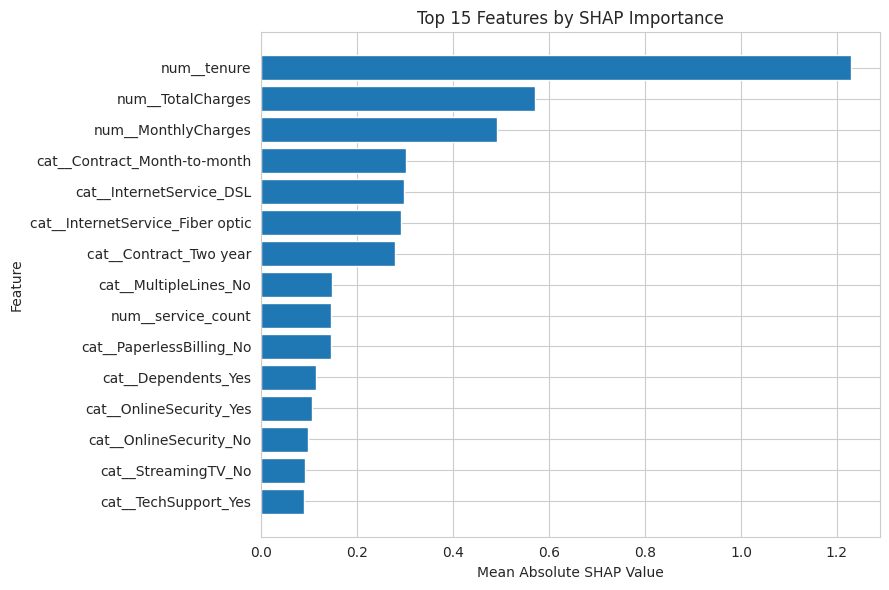

In [32]:
# Plot top 15 SHAP features

top_shap = shap_importance.head(15).sort_values(
    'Mean_Absolute_SHAP',
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_shap['Feature'],
    top_shap['Mean_Absolute_SHAP']
)

plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.title('Top 15 Features by SHAP Importance')
plt.tight_layout()
plt.show()

## Business Recommendations

The analysis identified several customer characteristics associated with higher churn risk. These findings can be translated into potential customer-retention strategies.

### 1. Focus on customers with short tenure

Customers in the **0–12 month** tenure group had the highest churn rate at **47.68%**, compared with only **6.61%** among customers with 61–72 months of tenure.

**Recommendation:**  
Introduce stronger onboarding and early-retention programs during the first year, such as proactive customer support, service check-ins, and targeted introductory offers.

### 2. Encourage longer-term contracts

Customers with **month-to-month contracts** had a churn rate of **42.71%**, compared with **11.28%** for one-year contracts and **2.85%** for two-year contracts.

**Recommendation:**  
Encourage customers to move from month-to-month plans toward longer-term contracts through appropriate discounts, bundled services, or loyalty incentives.

### 3. Monitor fiber-optic customers

Fiber-optic customers had a churn rate of **41.89%**, compared with **19.00%** for DSL customers and **7.43%** for customers without internet service.

**Recommendation:**  
Investigate whether pricing, service quality, support experience, or customer expectations are contributing to higher churn among fiber-optic customers.

### 4. Pay attention to electronic-check customers

Customers using **electronic check** had the highest churn rate among payment methods at **45.29%**, compared with 19.20% for mailed checks, 16.73% for automatic bank transfers, and 15.25% for automatic credit cards.

**Recommendation:**  
Consider encouraging customers to use automatic payment methods and investigate whether electronic-check customers differ in other characteristics associated with churn.

### 5. Use model-based risk identification

The final Logistic Regression model achieved a **ROC-AUC of 0.8359** and **80.45% accuracy** on the test set.

**Recommendation:**  
Use the model as a customer-risk screening tool to identify customers who may require retention attention. Model predictions should support, rather than replace, customer-service and business decision-making.

### 6. Prioritize the most influential features

The SHAP analysis identified **tenure, TotalCharges, MonthlyCharges, contract type, and Internet Service** among the most influential processed features in the final model.

These features can be incorporated into customer-risk monitoring and retention analysis to help prioritize potentially high-risk customer segments.

## Create Final Prediction Pipeline

The selected Logistic Regression model is combined with the preprocessing pipeline into a single end-to-end prediction pipeline.

This ensures that raw customer data can be passed directly to the model while numerical features are scaled and categorical features are one-hot encoded automatically.

In [46]:
from sklearn.pipeline import Pipeline

# Combine preprocessing and the selected Logistic Regression model
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', final_model)
])

print("Final prediction pipeline created successfully.")
print(final_pipeline)

Final prediction pipeline created successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'service_count']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_fr

## Verify Final Prediction Pipeline

Before saving the model, the complete pipeline is tested on the original test dataset.

The predictions should match the previously evaluated Logistic Regression model, confirming that combining preprocessing with the classifier does not change the model's results.

In [47]:
# Generate predictions using the complete pipeline
final_pipeline_predictions = final_pipeline.predict(X_test)
final_pipeline_probabilities = final_pipeline.predict_proba(X_test)[:, 1]

# Generate predictions using the previously evaluated Logistic Regression model
processed_X_test = preprocessor.transform(X_test)

original_predictions = final_model.predict(processed_X_test)
original_probabilities = final_model.predict_proba(processed_X_test)[:, 1]

print("Number of test predictions:", len(final_pipeline_predictions))

print(
    "Predictions match previous Logistic Regression:",
    np.array_equal(final_pipeline_predictions, original_predictions)
)

print(
    "Probabilities match previous Logistic Regression:",
    np.allclose(final_pipeline_probabilities, original_probabilities)
)

Number of test predictions: 1407
Predictions match previous Logistic Regression: True
Probabilities match previous Logistic Regression: True


In [36]:
# Verify that the pipeline can make predictions on the original test data

pipeline_predictions = final_pipeline.predict(X_test)
pipeline_probabilities = final_pipeline.predict_proba(X_test)[:, 1]

print("Pipeline predictions generated successfully.")
print("Number of predictions:", len(pipeline_predictions))
print("Number of test samples:", len(X_test))
print("First 10 predictions:", pipeline_predictions[:10])
print("First 10 churn probabilities:", pipeline_probabilities[:10])

Pipeline predictions generated successfully.
Number of predictions: 1407
Number of test samples: 1407
First 10 predictions: [0 1 0 0 0 0 0 0 1 0]
First 10 churn probabilities: [0.01752737 0.59271696 0.00476586 0.20170244 0.10236378 0.4722045
 0.026322   0.16525355 0.68005573 0.01544296]


## Save the Final Model

The complete preprocessing and Logistic Regression pipeline is saved using `joblib`.

Saving the complete pipeline ensures that the same preprocessing steps used during training are automatically applied when the model is used for future predictions or deployed in the Streamlit dashboard.

In [48]:
import os
import joblib

# Create the models directory in the project folder
models_dir = "/content/drive/MyDrive/customer_churn_prediction/models"
os.makedirs(models_dir, exist_ok=True)

# Save the complete prediction pipeline
model_path = os.path.join(
    models_dir,
    "churn_prediction_pipeline.pkl"
)

joblib.dump(final_pipeline, model_path)

print("Final pipeline saved successfully.")
print("Model path:")
print(model_path)

print("\nFile exists:", os.path.exists(model_path))
print(
    "File size:",
    round(os.path.getsize(model_path) / 1024, 2),
    "KB"
)

Final pipeline saved successfully.
Model path:
/content/drive/MyDrive/customer_churn_prediction/models/churn_prediction_pipeline.pkl

File exists: True
File size: 8.46 KB


## Verify Saved Model

The saved pipeline is reloaded from disk and tested on the test dataset.

This confirms that the saved model can reproduce the same predictions and probabilities as the pipeline used during development.

In [49]:
# Load the saved pipeline
loaded_pipeline = joblib.load(model_path)

# Generate predictions using the loaded pipeline
loaded_predictions = loaded_pipeline.predict(X_test)
loaded_probabilities = loaded_pipeline.predict_proba(X_test)[:, 1]

print("Saved pipeline loaded successfully.")
print("Predictions generated:", len(loaded_predictions))

print(
    "Predictions match original pipeline:",
    np.array_equal(
        final_pipeline_predictions,
        loaded_predictions
    )
)

print(
    "Probabilities match original pipeline:",
    np.allclose(
        final_pipeline_probabilities,
        loaded_probabilities
    )
)

Saved pipeline loaded successfully.
Predictions generated: 1407
Predictions match original pipeline: True
Probabilities match original pipeline: True


## Streamlit Dashboard

A lightweight Streamlit dashboard is created to demonstrate how the trained churn prediction pipeline can be used interactively.

The dashboard will allow users to enter customer characteristics, generate a churn probability, classify the customer into a risk category, and receive a basic retention recommendation.

In [50]:
!pip install streamlit --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 43.1 MB/s eta 0:00:00


In [51]:
import streamlit as st

print("Streamlit imported successfully.")

Streamlit imported successfully.


In [52]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import os

# --------------------------------------------------
# Page configuration
# --------------------------------------------------

st.set_page_config(
    page_title="Customer Churn Prediction",
    page_icon="📊",
    layout="wide"
)

st.title("📊 Customer Churn Prediction Dashboard")
st.write(
    "Predict customer churn risk and generate a basic retention recommendation."
)

# --------------------------------------------------
# Load model
# --------------------------------------------------

MODEL_PATH = (
    "/content/drive/MyDrive/"
    "customer_churn_prediction/models/"
    "churn_prediction_pipeline.pkl"
)

@st.cache_resource
def load_model():
    return joblib.load(MODEL_PATH)

model = load_model()

# --------------------------------------------------
# Customer information
# --------------------------------------------------

st.header("Customer Information")

col1, col2 = st.columns(2)

with col1:

    gender = st.selectbox(
        "Gender",
        ["Female", "Male"]
    )

    senior_citizen = st.selectbox(
        "Senior Citizen",
        [0, 1],
        format_func=lambda x: "Yes" if x == 1 else "No"
    )

    partner = st.selectbox(
        "Partner",
        ["Yes", "No"]
    )

    dependents = st.selectbox(
        "Dependents",
        ["Yes", "No"]
    )

    tenure = st.number_input(
        "Tenure (months)",
        min_value=0,
        max_value=72,
        value=12
    )

    phone_service = st.selectbox(
        "Phone Service",
        ["Yes", "No"]
    )

    multiple_lines = st.selectbox(
        "Multiple Lines",
        ["Yes", "No", "No phone service"]
    )

    internet_service = st.selectbox(
        "Internet Service",
        ["DSL", "Fiber optic", "No"]
    )

    online_security = st.selectbox(
        "Online Security",
        ["Yes", "No", "No internet service"]
    )

with col2:

    online_backup = st.selectbox(
        "Online Backup",
        ["Yes", "No", "No internet service"]
    )

    device_protection = st.selectbox(
        "Device Protection",
        ["Yes", "No", "No internet service"]
    )

    tech_support = st.selectbox(
        "Tech Support",
        ["Yes", "No", "No internet service"]
    )

    streaming_tv = st.selectbox(
        "Streaming TV",
        ["Yes", "No", "No internet service"]
    )

    streaming_movies = st.selectbox(
        "Streaming Movies",
        ["Yes", "No", "No internet service"]
    )

    contract = st.selectbox(
        "Contract",
        ["Month-to-month", "One year", "Two year"]
    )

    paperless_billing = st.selectbox(
        "Paperless Billing",
        ["Yes", "No"]
    )

    payment_method = st.selectbox(
        "Payment Method",
        [
            "Electronic check",
            "Mailed check",
            "Bank transfer (automatic)",
            "Credit card (automatic)"
        ]
    )

    monthly_charges = st.number_input(
        "Monthly Charges",
        min_value=0.0,
        value=70.0
    )

    total_charges = st.number_input(
        "Total Charges",
        min_value=0.0,
        value=monthly_charges * max(tenure, 1)
    )

# --------------------------------------------------
# Feature engineering
# --------------------------------------------------

service_columns = [
    online_security,
    online_backup,
    device_protection,
    tech_support,
    streaming_tv,
    streaming_movies
]

service_count = sum(
    value == "Yes"
    for value in service_columns
)

# --------------------------------------------------
# Prediction
# --------------------------------------------------

if st.button("Predict Churn Risk", type="primary"):

    customer = pd.DataFrame([{
        "gender": gender,
        "SeniorCitizen": senior_citizen,
        "Partner": partner,
        "Dependents": dependents,
        "tenure": tenure,
        "PhoneService": phone_service,
        "MultipleLines": multiple_lines,
        "InternetService": internet_service,
        "OnlineSecurity": online_security,
        "OnlineBackup": online_backup,
        "DeviceProtection": device_protection,
        "TechSupport": tech_support,
        "StreamingTV": streaming_tv,
        "StreamingMovies": streaming_movies,
        "Contract": contract,
        "PaperlessBilling": paperless_billing,
        "PaymentMethod": payment_method,
        "MonthlyCharges": monthly_charges,
        "TotalCharges": total_charges,
        "service_count": service_count
    }])

    probability = model.predict_proba(customer)[0, 1]

    prediction = int(probability >= 0.5)

    # --------------------------------------------------
    # Risk classification
    # --------------------------------------------------

    if probability >= 0.70:
        risk = "High Risk"
    elif probability >= 0.40:
        risk = "Medium Risk"
    else:
        risk = "Low Risk"

    # --------------------------------------------------
    # Display result
    # --------------------------------------------------

    st.header("Prediction Result")

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric(
            "Churn Probability",
            f"{probability:.1%}"
        )

    with col2:
        st.metric(
            "Predicted Churn",
            "Yes" if prediction == 1 else "No"
        )

    with col3:
        st.metric(
            "Risk Level",
            risk
        )

    # --------------------------------------------------
    # Retention recommendation
    # --------------------------------------------------

    st.subheader("Recommended Retention Action")

    if risk == "High Risk":

        if contract == "Month-to-month":
            recommendation = (
                "Offer a contract upgrade or loyalty incentive "
                "to encourage a longer-term commitment."
            )

        elif internet_service == "Fiber optic" and tech_support == "No":
            recommendation = (
                "Offer proactive technical support or a service "
                "review to address potential service-related friction."
            )

        elif tenure <= 12:
            recommendation = (
                "Prioritize early-life customer engagement with "
                "onboarding support and a targeted retention offer."
            )

        else:
            recommendation = (
                "Prioritize this customer for a personalized "
                "retention campaign."
            )

    elif risk == "Medium Risk":

        recommendation = (
            "Monitor the customer and consider a targeted loyalty "
            "or service engagement campaign."
        )

    else:

        recommendation = (
            "No immediate retention intervention is required. "
            "Continue normal customer engagement."
        )

    st.info(recommendation)

    # --------------------------------------------------
    # Customer details
    # --------------------------------------------------

    st.subheader("Customer Profile")

    st.dataframe(
        customer,
        use_container_width=True
    )

Writing app.py


In [63]:
!pip install -q streamlit
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 22 packages in 4s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸

## Streamlit Dashboard

A lightweight Streamlit dashboard was developed using the saved end-to-end churn prediction pipeline.

The dashboard is designed to:

- Accept customer demographic, service, contract, and billing information.
- Generate an individual churn probability.
- Classify customers into low-, medium-, and high-risk categories.
- Provide business-focused retention recommendations based on customer characteristics.

The dashboard uses the same preprocessing and Logistic Regression pipeline validated in this notebook, ensuring that raw customer inputs are transformed consistently with the training data.

The Streamlit application is available in `app.py`.

## Customer-Level Churn Risk Predictions

The selected Logistic Regression pipeline generates a churn probability for each customer in the test set.

Rather than treating churn as only a binary classification problem, the predicted probability is used to create practical customer risk segments. This allows the business to prioritize customers who are most likely to churn.

The risk segments used in this analysis are:

- **High Risk:** churn probability ≥ 70%
- **Medium Risk:** churn probability between 40% and 70%
- **Low Risk:** churn probability < 40%

These thresholds are analytical assumptions for prioritization and can be adjusted depending on the cost and capacity of a retention campaign.

In [75]:
# Generate customer-level predictions using the validated final pipeline

customer_predictions = X_test.copy()

customer_predictions['Actual_Churn'] = y_test.values

customer_predictions['Churn_Probability'] = final_pipeline.predict_proba(X_test)[:, 1]

customer_predictions['Predicted_Churn'] = (
    customer_predictions['Churn_Probability'] >= 0.50
).astype(int)

# Create business-oriented risk segments
customer_predictions['Risk_Segment'] = pd.cut(
    customer_predictions['Churn_Probability'],
    bins=[-np.inf, 0.40, 0.70, np.inf],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Display sample
customer_predictions[
    [
        'Churn_Probability',
        'Predicted_Churn',
        'Risk_Segment',
        'tenure',
        'MonthlyCharges',
        'Contract'
    ]
].head(10)

,Churn_Probability,Predicted_Churn,Risk_Segment,tenure,MonthlyCharges,Contract
971,0.017527,0,Low Risk,59,75.95,Two year
618,0.592717,1,Medium Risk,7,78.55,Month-to-month
4282,0.004766,0,Low Risk,54,20.10,Two year
3715,0.201702,0,Low Risk,2,20.65,Month-to-month
4525,0.102364,0,Low Risk,71,105.15,Two year
445,0.472205,0,Medium Risk,60,105.90,Month-to-month
5889,0.026322,0,Low Risk,33,24.15,One year
3381,0.165254,0,Low Risk,7,20.65,Month-to-month
1341,0.680056,1,Medium Risk,14,87.25,Month-to-month
5681,0.015443,0,Low Risk,72,61.20,Two year


## Churn Risk Segment Distribution

The predicted probabilities are grouped into three risk segments to make the model output easier to interpret from a business perspective.

The purpose of this segmentation is not to claim that every customer above a particular probability will churn. Instead, it provides a practical framework for prioritizing retention efforts.

In [76]:
# Count customers in each risk segment
risk_summary = (
    customer_predictions['Risk_Segment']
    .value_counts()
    .reindex(['Low Risk', 'Medium Risk', 'High Risk'])
)

risk_percentage = (
    risk_summary / len(customer_predictions) * 100
).round(2)

risk_table = pd.DataFrame({
    'Customers': risk_summary,
    'Percentage': risk_percentage
})

display(risk_table)

,Customers,Percentage
Risk_Segment,,
Low Risk,965,68.59
Medium Risk,359,25.52
High Risk,83,5.90


## High-Risk Customer Analysis

The high-risk segment contains customers with a predicted churn probability of at least 70%.

These customers represent the highest-priority group for potential retention activity. However, a high predicted probability indicates elevated risk rather than a guaranteed churn outcome.

The analysis below examines the characteristics of high-risk customers to identify patterns that can inform targeted retention strategies.

In [77]:
# Filter high-risk customers
high_risk_customers = customer_predictions[
    customer_predictions['Risk_Segment'] == 'High Risk'
].copy()

print("High-risk customers:", len(high_risk_customers))
print(
    "Average churn probability:",
    round(high_risk_customers['Churn_Probability'].mean() * 100, 2),
    "%"
)

print(
    "Average monthly charges:",
    round(high_risk_customers['MonthlyCharges'].mean(), 2)
)

print(
    "Average tenure:",
    round(high_risk_customers['tenure'].mean(), 2),
    "months"
)

print("\nContract distribution:")
display(
    high_risk_customers['Contract']
    .value_counts()
    .to_frame('Customers')
)

High-risk customers: 83
Average churn probability: 75.0 %
Average monthly charges: 84.14
Average tenure: 6.43 months

Contract distribution:


,Customers
Contract,
Month-to-month,83


## Revenue Exposure from High-Risk Customers

The high-risk segment represents customers with elevated predicted churn probability. To understand the potential business significance of this segment, we estimate the monthly recurring revenue associated with these customers.

This is a measure of **revenue exposure**, not guaranteed revenue loss. It assumes that the current monthly charge represents the recurring revenue associated with each customer.

The analysis can help prioritize retention efforts toward customers who combine high churn risk with meaningful monthly revenue.

In [78]:
# Calculate revenue exposure for high-risk customers

high_risk_monthly_revenue = high_risk_customers['MonthlyCharges'].sum()

high_risk_average_revenue = high_risk_customers['MonthlyCharges'].mean()

print(
    "High-risk customers:",
    len(high_risk_customers)
)

print(
    "Average monthly charge per high-risk customer:",
    round(high_risk_average_revenue, 2)
)

print(
    "Total monthly revenue exposure:",
    round(high_risk_monthly_revenue, 2)
)

High-risk customers: 83
Average monthly charge per high-risk customer: 84.14
Total monthly revenue exposure: 6983.85


## Business-Focused Retention Recommendations

The model predictions can be translated into practical retention priorities by examining the characteristics of high-risk customers.

In this test population, all 83 high-risk customers are on month-to-month contracts, with an average tenure of approximately 6.4 months and an average monthly charge of approximately 84.14.

Based on these observed characteristics, the following retention actions are recommended:

1. **Prioritize month-to-month customers**
   - Offer targeted incentives for moving to longer-term contracts.
   - Emphasize the value and stability of longer-term plans.

2. **Focus on early-tenure customers**
   - Introduce proactive onboarding and engagement programs during the first several months.
   - Monitor new customers more closely for early signs of dissatisfaction.

3. **Prioritize higher-value at-risk customers**
   - Customers with both high churn probability and relatively high monthly charges represent greater revenue exposure.
   - These customers can receive higher-priority retention outreach.

4. **Use model explanations to personalize interventions**
   - SHAP feature importance can help identify the factors contributing most strongly to individual churn predictions.
   - Retention actions should therefore be targeted rather than applying the same offer to every at-risk customer.

These recommendations are based on observed patterns and model predictions. They should be validated through controlled retention campaigns before being treated as causal business strategies.

## Retention Priority

Churn probability alone does not capture the potential business value of a customer. A customer with high churn probability and a higher monthly charge may represent greater revenue exposure than a lower-value customer with the same level of risk.

A simple retention-priority framework is therefore created by combining predicted churn risk with monthly charges.

This is a prioritization heuristic rather than a financial or causal model.

In [79]:
# Create a simple retention-priority score
customer_predictions['Retention_Priority'] = (
    customer_predictions['Churn_Probability']
    * customer_predictions['MonthlyCharges']
)

# Rank customers by retention priority
priority_customers = customer_predictions.sort_values(
    'Retention_Priority',
    ascending=False
).copy()

# Display the highest-priority customers
priority_customers[
    [
        'Churn_Probability',
        'MonthlyCharges',
        'Retention_Priority',
        'Risk_Segment',
        'tenure',
        'Contract'
    ]
].head(10)

,Churn_Probability,MonthlyCharges,Retention_Priority,Risk_Segment,tenure,Contract
2792,0.815782,100.95,82.353177,High Risk,3,Month-to-month
2626,0.826803,99.25,82.060151,High Risk,7,Month-to-month
2443,0.778514,104.85,81.627197,High Risk,14,Month-to-month
3949,0.767518,105.30,80.819617,High Risk,6,Month-to-month
3374,0.847545,95.10,80.601565,High Risk,1,Month-to-month
3154,0.845748,94.85,80.219229,High Risk,3,Month-to-month
6828,0.786078,100.75,79.197377,High Risk,11,Month-to-month
3721,0.815777,96.60,78.804089,High Risk,3,Month-to-month
2289,0.738331,106.70,78.779957,High Risk,12,Month-to-month
4693,0.743941,104.35,77.630262,High Risk,21,Month-to-month


## Final Business Insights

The analysis identified several meaningful patterns associated with customer churn:

### Customer behavior

- Overall churn in the cleaned dataset was **26.58%**.
- Customers with shorter tenure showed substantially higher churn rates. The churn rate was **47.68% for customers with 0–12 months of tenure**, compared with **6.61% for customers with 61–72 months**.
- Contract type was strongly associated with churn. The churn rate was **42.71% for month-to-month customers**, compared with **11.28% for one-year contracts** and **2.85% for two-year contracts**.
- Fiber optic customers had a higher observed churn rate (**41.89%**) than DSL (**19.00%**) and customers without internet service (**7.43%**).
- Electronic check customers had the highest observed churn rate among payment methods (**45.29%**).

### Predictive modeling

Three classification models were evaluated:

- Logistic Regression
- XGBoost
- Random Forest

Logistic Regression was selected as the final model based on its overall balance of performance metrics and its **ROC-AUC of 0.8359**.

The final Logistic Regression model achieved:

- **Accuracy:** 80.45%
- **Precision:** 64.95%
- **Recall:** 57.49%
- **F1-score:** 60.99%
- **ROC-AUC:** 83.59%

Because churn is the minority class, the model was evaluated using multiple metrics rather than accuracy alone.

### Model explainability

SHAP analysis was used to understand which transformed features contributed most strongly to the model's predictions.

The largest mean absolute SHAP values were associated with:

1. Tenure
2. Total Charges
3. Monthly Charges
4. Month-to-month contract
5. Internet service type
6. Two-year contract
7. Multiple lines
8. Service count

This provides additional interpretability beyond the model's predictive performance.

### Customer risk prioritization

The final prediction pipeline was used to assign customers to practical risk segments.

Among the 1,407 test customers:

- **965 (68.59%)** were classified as Low Risk.
- **359 (25.52%)** were classified as Medium Risk.
- **83 (5.90%)** were classified as High Risk.

The 83 high-risk customers had:

- Average predicted churn probability of **75.00%**
- Average monthly charge of **84.14**
- Average tenure of **6.43 months**
- **Month-to-month contracts for all 83 customers**

Their combined monthly charges represented approximately **6,983.85 in monthly revenue exposure**.

This figure represents revenue exposure associated with high-risk customers and should not be interpreted as guaranteed future revenue loss.

### Retention strategy

Based on these findings, retention efforts could prioritize:

- Early-tenure customers with elevated churn probability.
- Month-to-month customers with high predicted risk.
- Higher-value customers where high churn probability overlaps with higher monthly charges.
- Personalized interventions informed by model explanations.

Potential interventions include contract upgrade incentives, proactive onboarding, service/support outreach, and targeted retention offers.

These recommendations are based on observed patterns and model predictions. They should be validated through controlled retention campaigns before being interpreted as causal effects.

## Limitations and Future Improvements

This project demonstrates a predictive churn-analysis workflow using historical customer-level data. Several limitations should be considered:

1. **Historical observational data:** The analysis identifies associations and predictive patterns but does not establish that individual features causally cause churn.

2. **Revenue exposure:** Revenue-at-risk calculations are scenario-free exposure estimates based on current monthly charges. They do not represent guaranteed revenue loss.

3. **Retention recommendations:** Recommended interventions have not been tested through randomized experiments, so their actual effectiveness would need to be measured through controlled campaigns.

4. **Model generalization:** Model performance was evaluated on a held-out test set from the same dataset. Performance should be monitored if the model is applied to a different customer population or future data.

5. **Threshold selection:** The current risk segmentation thresholds are analytical prioritization rules and can be adjusted according to campaign capacity and the relative costs of false positives and false negatives.

### Future Improvements

Future versions could include:

- Hyperparameter tuning and cross-validation.
- More systematic probability-threshold optimization.
- Time-based validation using future customer observations.
- Automated model monitoring.
- A/B testing of retention interventions.
- Integration with a production customer database.
- A more complete interactive dashboard for customer-level decision support.